# Image Compression using Singular value decomposition

## Let's compress AILab Logo for fun

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.io import imread

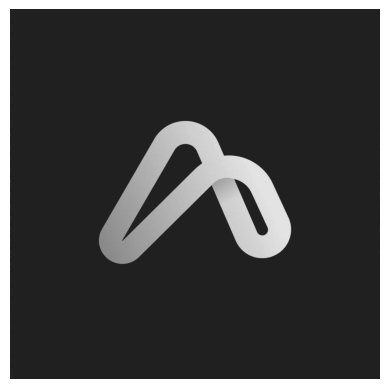

In [36]:
ailab_logo_path = "./Images/ailablogo.jpg"
ailab_logo = rgb2gray(imread(ailab_logo_path))
plt.axis('off')
plt.imshow(ailab_logo, cmap='gray')

In [30]:
def compress_image_svd(image_path, k_values):
    image = rgb2gray(imread(image_path))
    U, S, Vt = np.linalg.svd(image, full_matrices=False)
    
    fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(15, 5))
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    
    # reconstructing images with different k values
    for i, k in enumerate(k_values):
        compressed_image = (U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :])
        axes[i + 1].imshow(compressed_image, cmap='gray')
        axes[i + 1].set_title(f"k={k}")
        axes[i + 1].axis("off")
    
    plt.show()

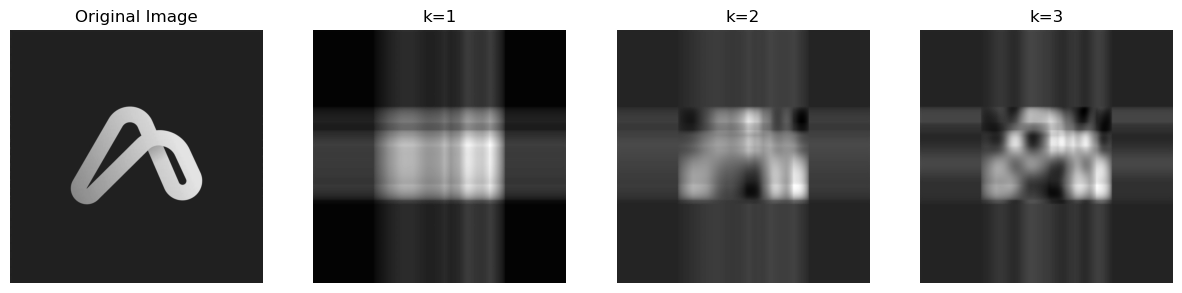

In [31]:
k_values = [i for i in range(1, 4)]  # compression levels
compress_image_svd(ailab_logo_path, k_values)

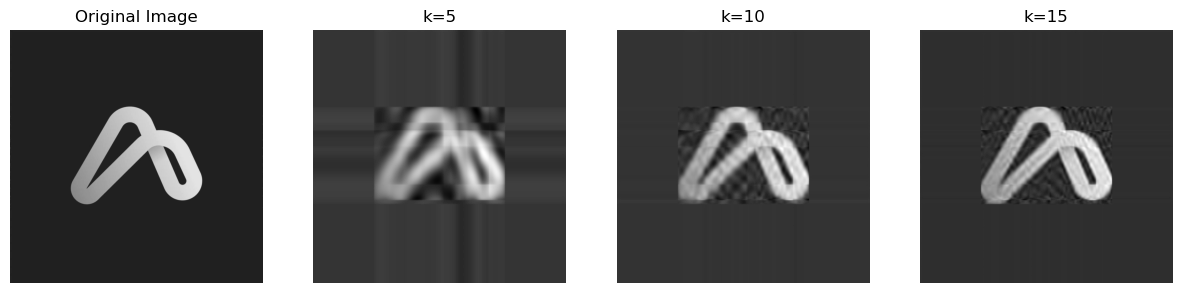

In [32]:
k_values = [i for i in range(5, 20, 5)]
compress_image_svd(ailab_logo_path, k_values)

## Now, let's compress random photo from my gallery

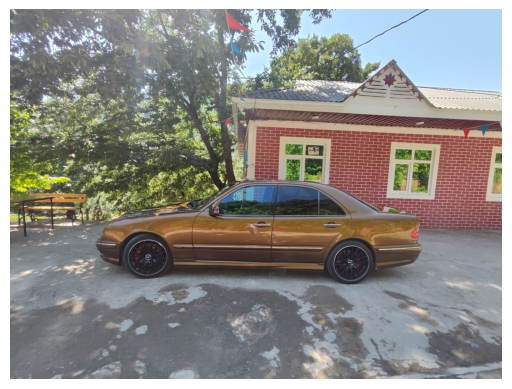

In [39]:
car_image_path = "./Images/car.jpg"
car_image = imread(car_image_path)
plt.axis('off')
plt.imshow(car_image, cmap='gray')

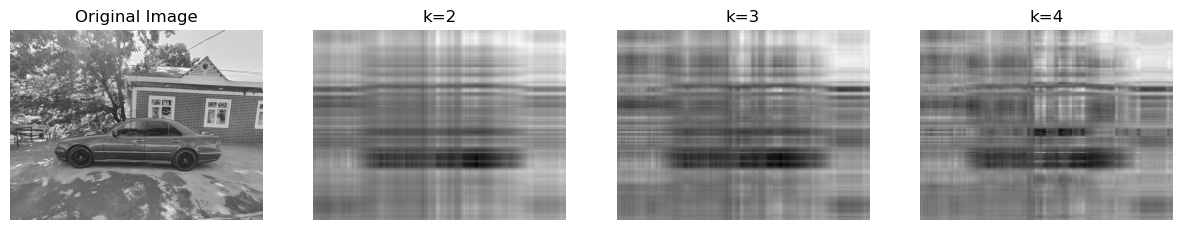

In [42]:
k_values = [i for i in range(2, 5)]
compress_image_svd(car_image_path, k_values)

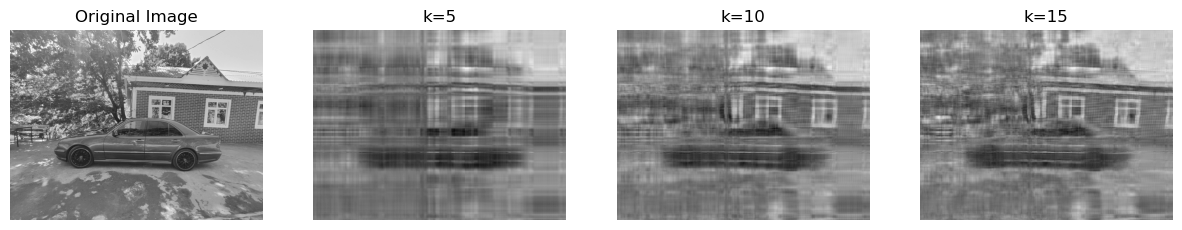

In [43]:
k_values = [i for i in range(5, 20, 5)]
compress_image_svd(car_image_path, k_values)